In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

In [4]:
display_quintiles = {
    1: "Poorest",
    2: "Second",
    3: "Third",
    4: "Fourth",
    5: "Wealthiest",
}

In [ ]:
daly_categories = {
    "ntd": "NTD DALYs",
    "anemia": "Anemia DALYs",
    "lbwsg": "Child YLLs",
    "maternal_disorders": "Maternal disorders DALYs",
}

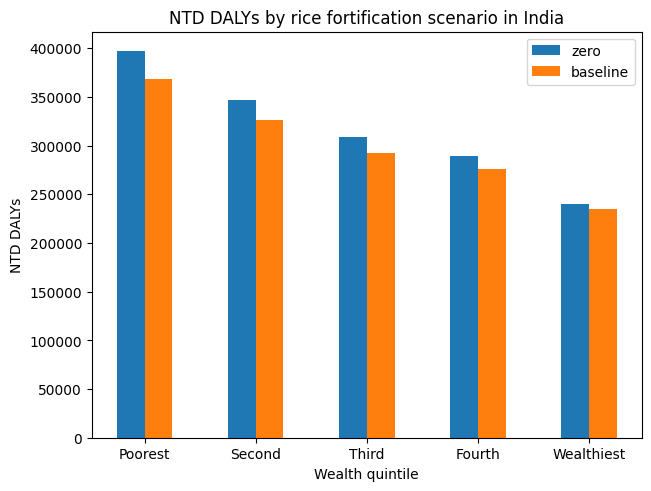

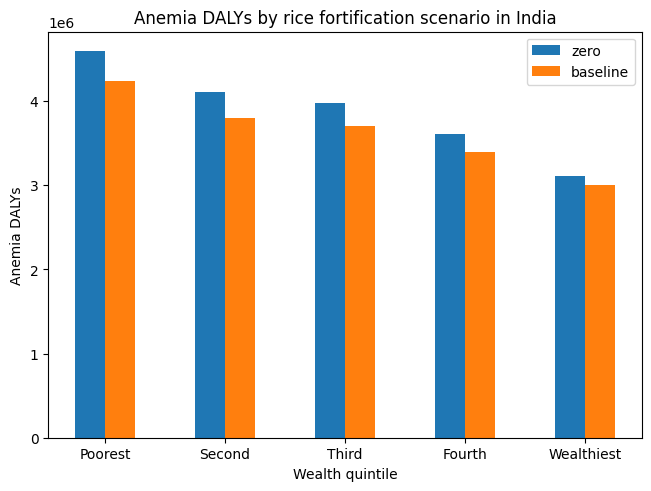

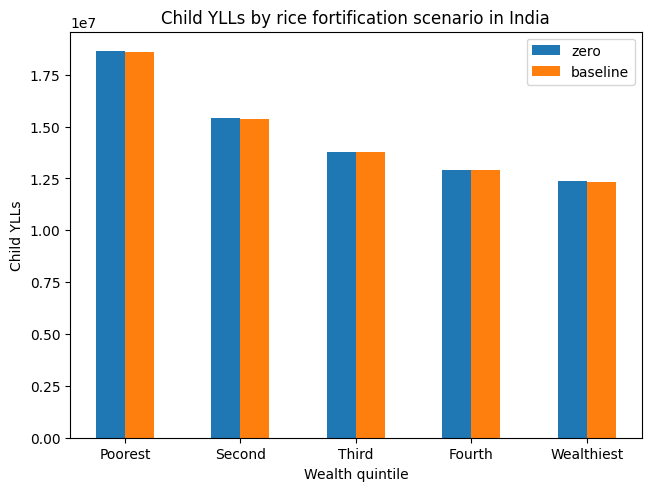

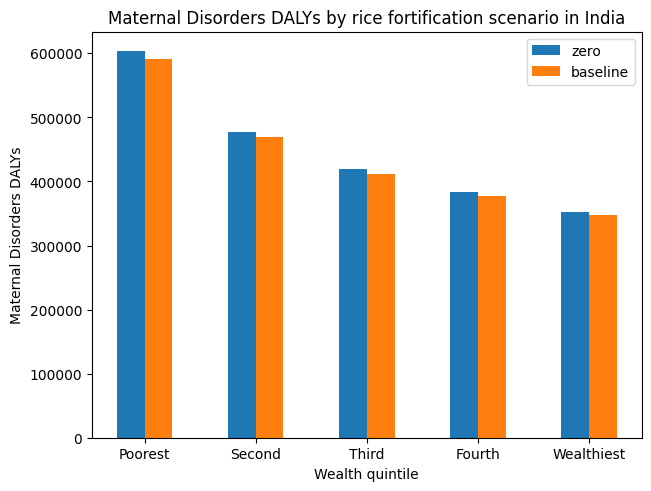

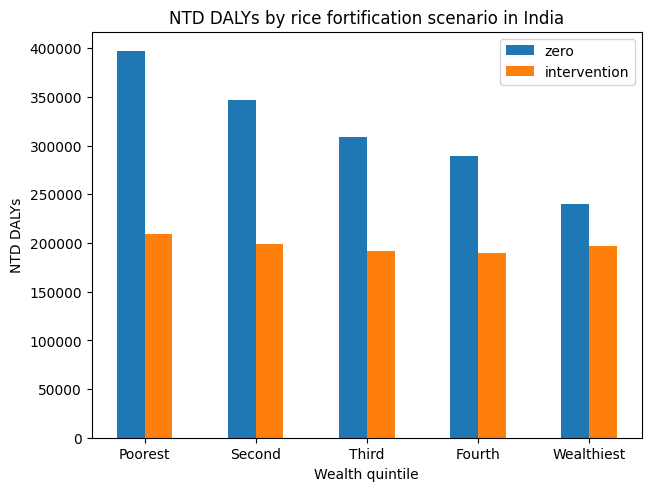

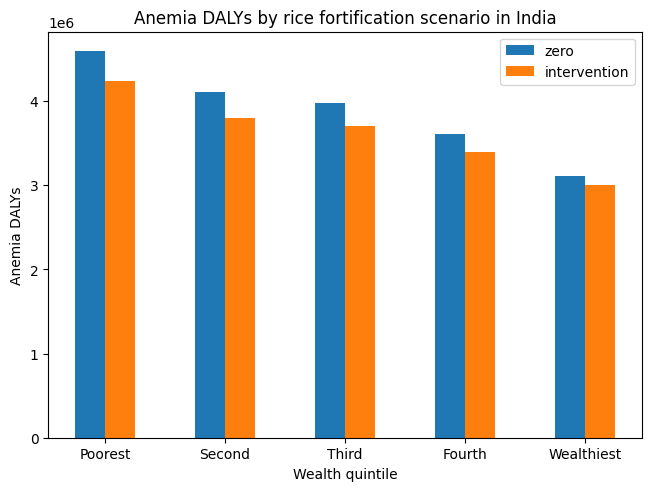

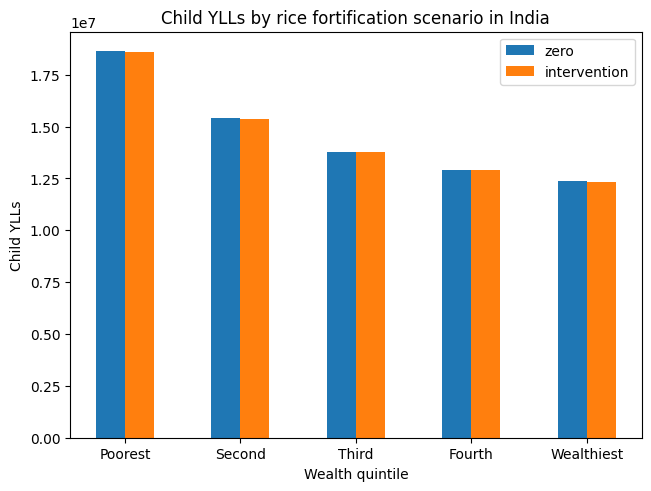

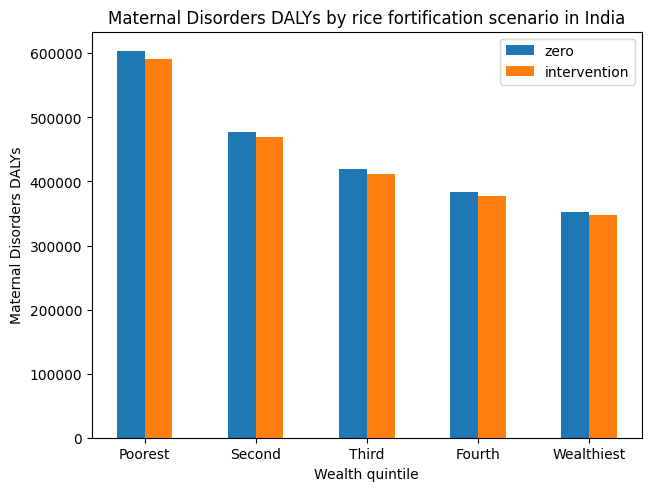

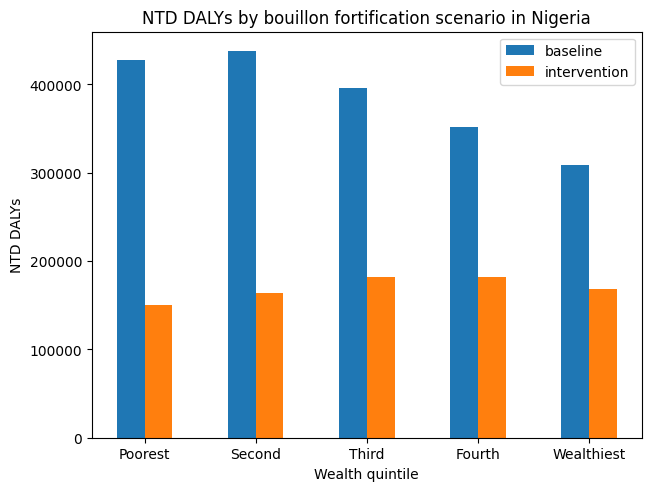

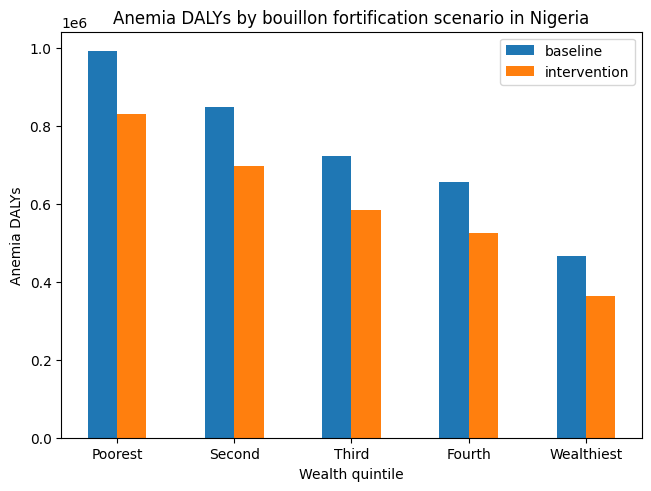

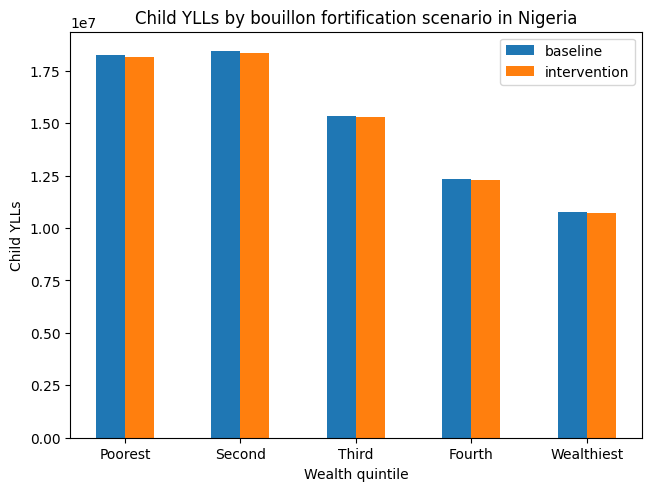

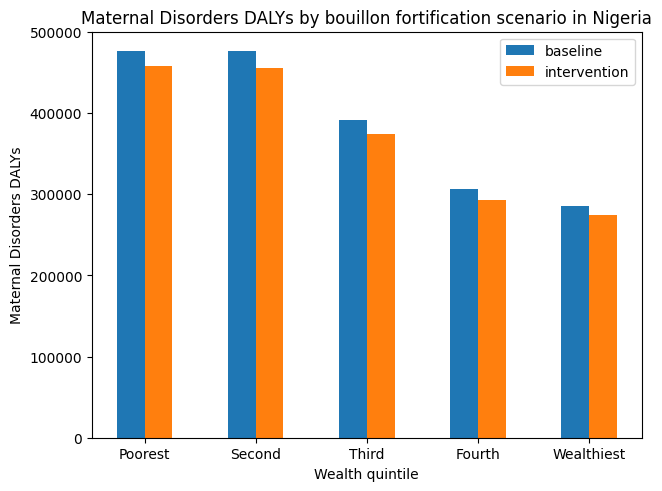

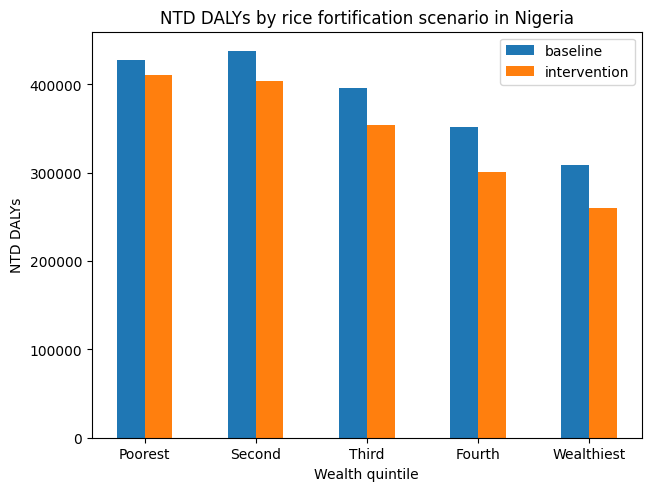

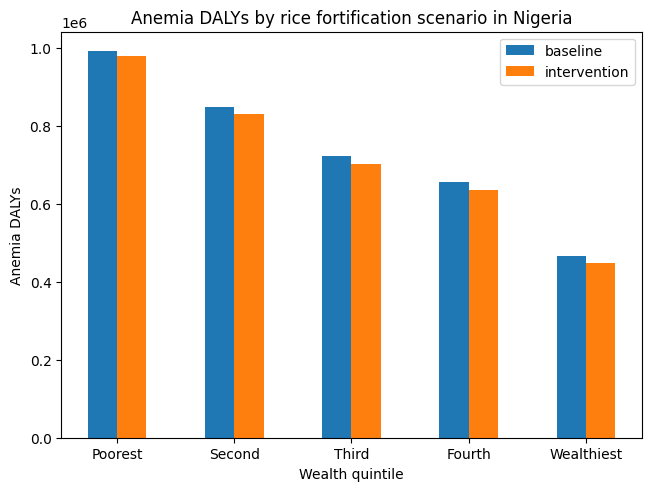

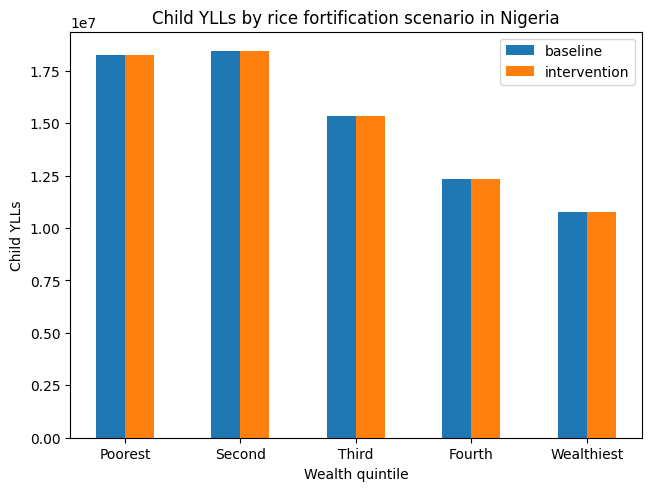

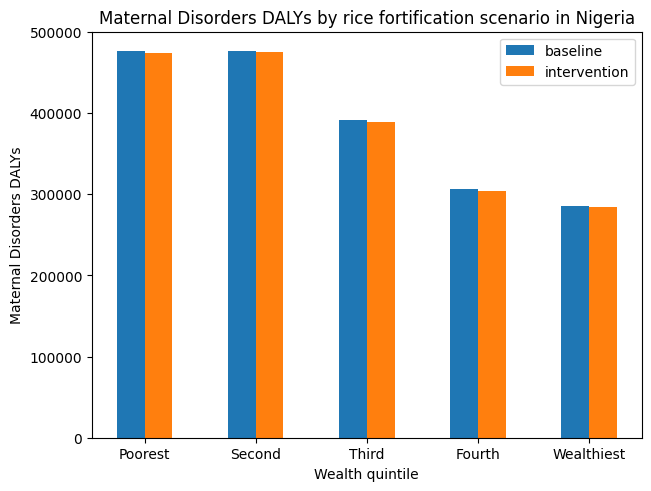

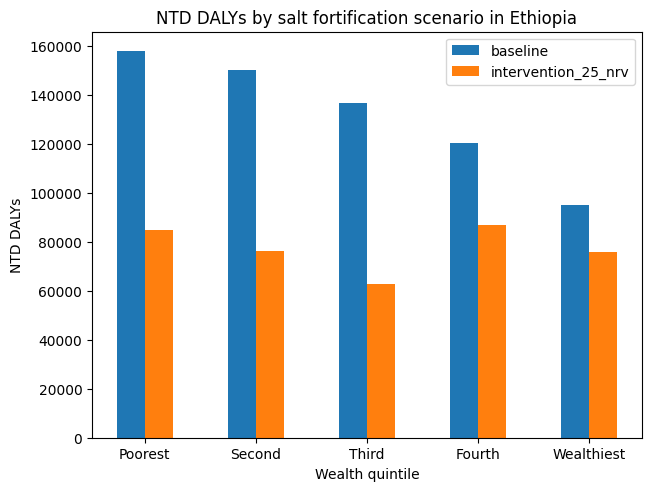

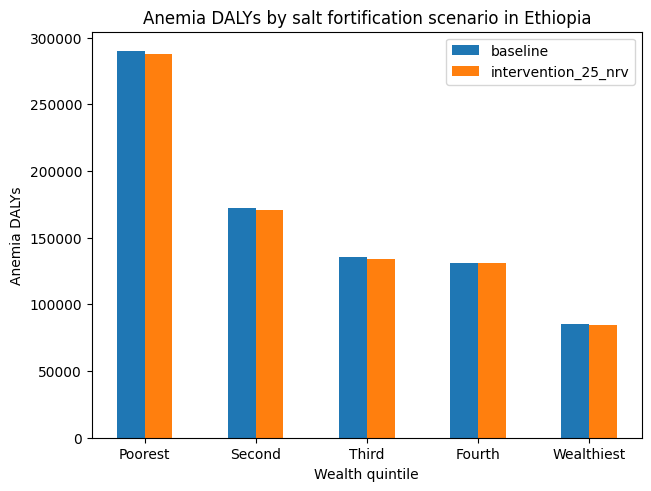

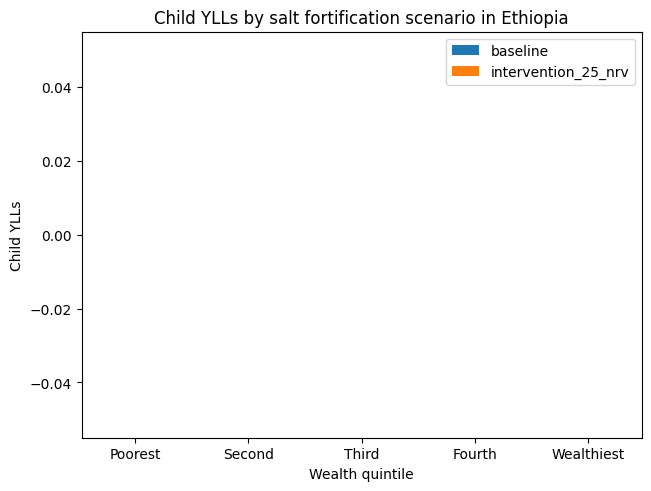

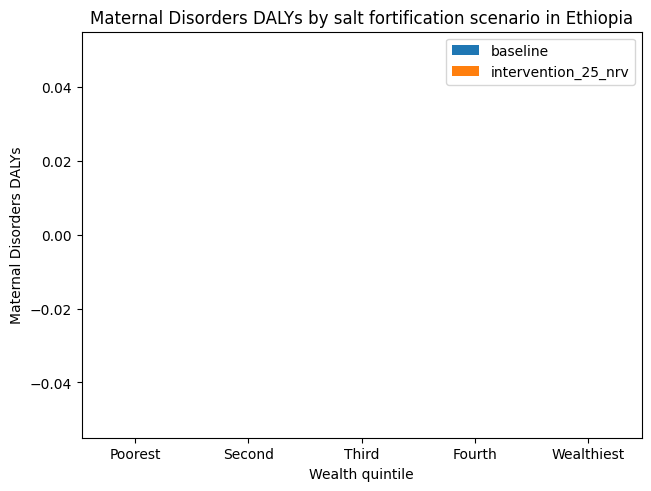

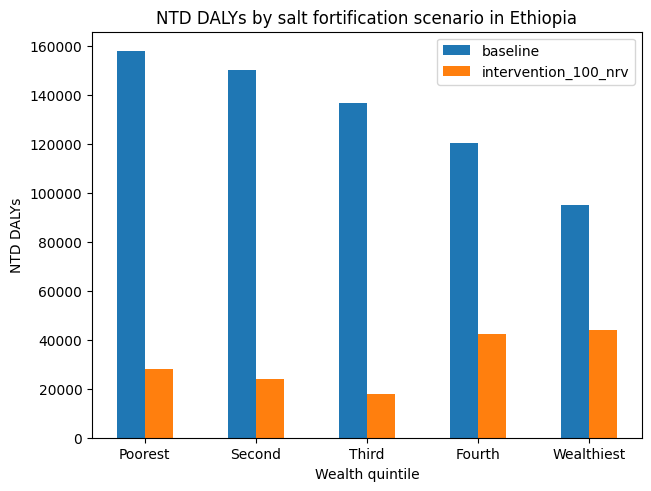

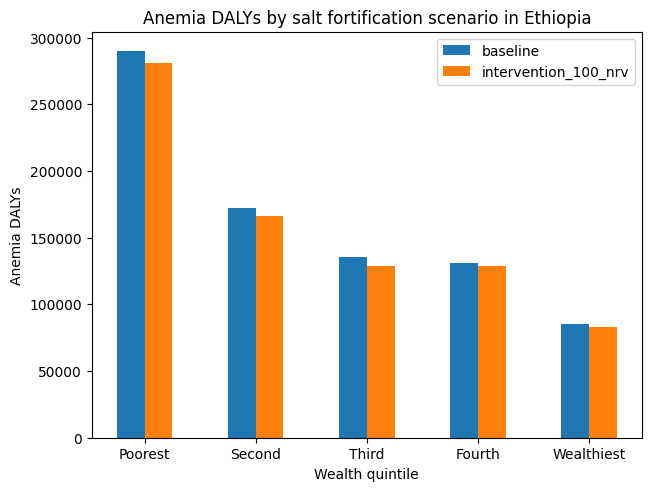

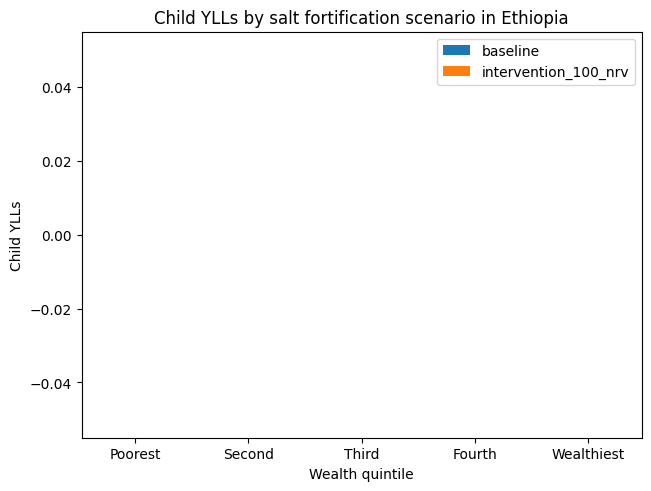

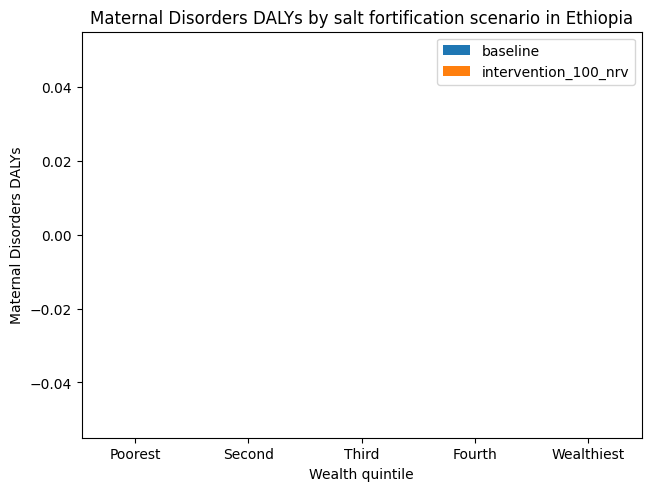

In [22]:
for _, (
    location,
    vehicle,
    baseline_scenario,
    intervention_scenario,
    custom_name,
) in pd.read_csv("../0050_config/location_vehicle_scenario_comparisons.csv").iterrows():
    dalys_by_scenario = pd.read_csv(f"./results/{location}/{vehicle}/dalys_by_scenario.csv")

    for category, category_name in daly_categories.items():
        category_dalys_by_scenario = dalys_by_scenario.set_index(['entity', 'scenario', 'wealth_quintile']).loc[category]

        baseline_dalys = category_dalys_by_scenario.loc[baseline_scenario].reset_index()
        intervention_dalys = category_dalys_by_scenario.loc[intervention_scenario].reset_index()
        assert set(baseline_dalys.wealth_quintile.unique()) == set(intervention_dalys.wealth_quintile.unique())
        quintiles = display_quintiles.values()

        x = np.arange(len(quintiles))  # the label locations
        width = 0.25  # the width of the bars
        multiplier = 0

        fig, ax = plt.subplots(layout='constrained')

        offset = width * multiplier
        rects = ax.bar(x + offset, baseline_dalys.set_index('wealth_quintile').value.loc[display_quintiles.keys()], width, label=baseline_scenario)
        multiplier += 1

        offset = width * multiplier
        rects = ax.bar(x + offset, intervention_dalys.set_index('wealth_quintile').value.loc[display_quintiles.keys()], width, label=intervention_scenario)
        multiplier += 1

        ax.set_ylabel(category_name)
        ax.set_xlabel('Wealth quintile')
        ax.set_title(f'{category_name} by {vehicle} fortification scenario in {location.title()}')
        ax.set_xticks(x + width * 0.5, quintiles)
        ax.legend(loc='upper right')

        plt.show()